<a href="https://colab.research.google.com/github/sxdattt/NorthStar-Urban-Mobility-Analytics/blob/main/notebooks/R_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell installs and loads all the required R packages for the analysis. These packages enable functionalities such as SQL queries on data frames (`sqldf`), tidy data manipulation (`dplyr`, `tidyr`), data visualization (`ggplot2`, `scales`), date/time parsing (`lubridate`), and clean table printing (`knitr`).

# ── CELL 1 ── Install & Load Packages

In [1]:


install.packages(c("sqldf", "dplyr", "tidyr", "ggplot2",
                   "scales", "lubridate", "knitr"),
                 repos = "https://cloud.r-project.org",
                 quiet = TRUE)

library(sqldf)
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(lubridate)
library(knitr)

cat("✅ All packages loaded successfully.\n")

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




✅ All packages loaded successfully.


In [2]:
# ──── Load All CSVs from GitHub ────────────────────────────

GITHUB_RAW <- "https://raw.githubusercontent.com/sxdattt/NorthStar-Urban-Mobility-Analytics/main/"


load_csv <- function(filename, subfolder = "") {
  url      <- paste0(GITHUB_RAW, subfolder, filename)
  tmp_file <- tempfile(fileext = ".csv")

  result <- tryCatch({
    download.file(url, destfile = tmp_file, method = "curl", quiet = TRUE)
    df <- read.csv(tmp_file, stringsAsFactors = FALSE,
                   na.strings = c("", "NA", "N/A"))
    cat(sprintf("  ✅ %-30s → %d rows × %d cols\n", filename, nrow(df), ncol(df)))
    df
  }, error = function(e) {
    cat(sprintf("  ❌ %-30s → FAILED: %s\n", filename, e$message))
    NULL
  })

  unlink(tmp_file)  # clean up temp file
  result
}


SUBFOLDER <- ""


# ── Load all 11 datasets ─────────────────────────────────────────────────────
cat("📥 Loading NorthStar datasets from GitHub...\n\n")

orders       <- load_csv("orders.csv",          SUBFOLDER)
deliveries   <- load_csv("deliveries.csv",       SUBFOLDER)
customers    <- load_csv("customers.csv",         SUBFOLDER)
complaints   <- load_csv("complaints.csv",        SUBFOLDER)
drivers      <- load_csv("drivers.csv",           SUBFOLDER)
vehicles     <- load_csv("vehicles.csv",          SUBFOLDER)
hubs         <- load_csv("hubs.csv",              SUBFOLDER)
incidents    <- load_csv("incidents.csv",         SUBFOLDER)
app_events   <- load_csv("app_events.csv",        SUBFOLDER)
data_dict    <- load_csv("data_dictionary.csv",   SUBFOLDER)

# ── Final status check ───────────────────────────────────────────────────────
loaded <- Filter(Negate(is.null),
                 list(orders=orders, deliveries=deliveries, customers=customers,
                      complaints=complaints, drivers=drivers, vehicles=vehicles,
                      hubs=hubs, incidents=incidents, app_events=app_events,
                      data_dict=data_dict))

cat(sprintf("\n📊 Successfully loaded: %d / 10 datasets\n", length(loaded)))

if (length(loaded) == 10) {
  cat("✅ All datasets ready.")
} else {
  cat("⚠️  Some datasets failed. Check subfolder path and file names on GitHub.\n")
  cat("   Go to your GitHub repo → click a CSV → click Raw → copy the URL.\n")
  cat("   The path after /main/ is your SUBFOLDER + filename.\n")
}

📥 Loading NorthStar datasets from GitHub...

  ✅ orders.csv                     → 1250 rows × 11 cols
  ✅ deliveries.csv                 → 950 rows × 13 cols
  ✅ customers.csv                  → 650 rows × 9 cols
  ✅ complaints.csv                 → 320 rows × 10 cols
  ✅ drivers.csv                    → 170 rows × 8 cols
  ✅ vehicles.csv                   → 120 rows × 8 cols
  ✅ hubs.csv                       → 8 rows × 5 cols
  ✅ incidents.csv                  → 280 rows × 7 cols
  ✅ app_events.csv                 → 640 rows × 10 cols
  ✅ data_dictionary.csv            → 9 rows × 3 cols

📊 Successfully loaded: 10 / 10 datasets
✅ All datasets ready.

In [3]:
# ──── Data Inspection: Shape, Types, and Sample Records ─────────────

inspect_df <- function(name, df) {
  cat(sprintf("\n══ %s (%d rows × %d cols) ══\n", name, nrow(df), ncol(df)))
  cat("Columns:", paste(names(df), collapse = ", "), "\n")
  cat("Types  :", paste(sapply(df, class), collapse = ", "), "\n")
}

inspect_df("orders",     orders)
inspect_df("deliveries", deliveries)
inspect_df("customers",  customers)
inspect_df("complaints", complaints)
inspect_df("drivers",    drivers)
inspect_df("vehicles",   vehicles)
inspect_df("hubs",       hubs)
inspect_df("incidents",  incidents)
inspect_df("app_events", app_events)


══ orders (1250 rows × 11 cols) ══
Columns: order_id, customer_id, service_type, order_created_at, promised_window_hours, pickup_zone, dropoff_zone, priority_level, order_value, booking_channel, special_handling_flag 
Types  : character, character, character, character, integer, character, character, character, numeric, character, integer 

══ deliveries (950 rows × 13 cols) ══
Columns: delivery_id, order_id, driver_id, vehicle_id, hub_id, dispatch_time, delivery_completed_at, delivery_status, route_distance_km, manual_route_override_count, proof_of_completion_missing, customer_rating_post_delivery, fuel_or_charge_cost 
Types  : character, character, character, character, character, character, character, character, numeric, integer, integer, numeric, numeric 

══ customers (650 rows × 9 cols) ══
Columns: customer_id, age, home_zone, customer_type, signup_date, loyalty_score, app_engagement_score, preferred_channel, account_status 
Types  : character, integer, character, character, cha

## Exploratory Data Analysis

── Summary Statistics: Orders ──


      order_id       customer_id      service_type   order_created_at
 Length   :1250   Length   :1250   Length   :1250   Length   :1250   
 N.unique :1250   N.unique : 568   N.unique :   5   N.unique :1248   
 N.blank  :   0   N.blank  :   0   N.blank  :   0   N.blank  :   0   
 Min.nchar:   6   Min.nchar:   5   Min.nchar:   6   Min.nchar:  19   
 Max.nchar:   6   Max.nchar:   5   Max.nchar:   9   Max.nchar:  19   
                                                                     
 promised_window_hours    pickup_zone      dropoff_zone    priority_level
 Min.   : 1.000        Length   :1250   Length   :1250   Length   :1250  
 1st Qu.: 4.000        N.unique :  16   N.unique :  16   N.unique :   4  
 Median : 6.000        N.blank  :   0   N.blank  :   0   N.blank  :   0  
 Mean   : 7.622        Min.nchar:   3   Min.nchar:   3   Min.nchar:   3  
 3rd Qu.:12.000        Max.nchar:   9   Max.nchar:   9   Max.nchar:   8  
 Max.   :24.000                                                   


── Cardinality Analysis ──
  service_type              → 5 unique values: Passenger, Parcel, Retail, Business, Medical
  pickup_zone               → 16 unique values: Airport, North, West, RiverSide, Riverside, CENTRAL, NORTH, South, WEST, East, Ctr, SOUTH, Central, AIRPORT, north, EAST


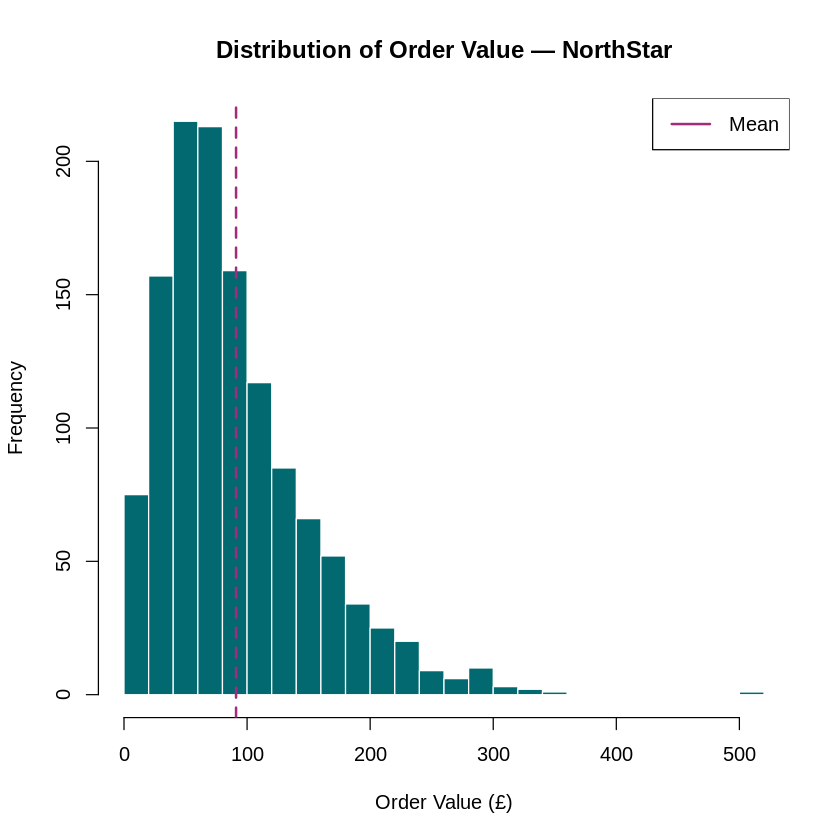

In [4]:
# ──EDA in R ──────────────────────────────────────────────────────

## 1. Summary statistics (R's built-in EDA tool)
cat("── Summary Statistics: Orders ──\n")
summary(orders)

## 2. Cardinality check in R
cat("\n── Cardinality Analysis ──\n")
cat_cols <- c("service_type","order_status","hub_id","driver_id","pickup_zone")
for (col in cat_cols) {
  if (col %in% names(orders)) {
    cat(sprintf("  %-25s → %d unique values: %s\n",
        col,
        length(unique(orders[[col]])),
        paste(unique(orders[[col]]), collapse=", ")))
  }
}

## 3. Distribution of order_value
hist(orders$order_value,
     main = "Distribution of Order Value — NorthStar",
     xlab = "Order Value (£)",
     col  = "#01696f",
     border = "white",
     breaks = 30)
abline(v = mean(orders$order_value, na.rm=TRUE),
       col = "#a12c7b", lwd = 2, lty = 2)
legend("topright", legend = "Mean", col = "#a12c7b", lwd = 2)

# ----- Data Cleaning --------------

In [5]:
## 4a. Missing-value audit across all loaded tables
tables_list <- list(
  orders = orders, deliveries = deliveries, customers = customers,
  complaints = complaints, drivers = drivers, vehicles = vehicles,
  hubs = hubs, incidents = incidents, app_events = app_events
)

na_audit <- lapply(names(tables_list), function(nm) {
  df  <- tables_list[[nm]]
  nas <- colSums(is.na(df))
  data.frame(
    table    = nm,
    column   = names(nas),
    na_count = as.integer(nas),
    na_pct   = round(100 * nas / nrow(df), 1)
  )
}) %>% bind_rows() %>% filter(na_count > 0) %>% arrange(desc(na_pct))

cat("── Missing-value summary  ──\n")
kable(na_audit, col.names = c("Table", "Column", "NA Count", "NA %"))

# ════════════════════════════════════════════════════════════════════════════
## 4b. Print raw samples to detect date formats visually
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Raw date/datetime samples (before parsing) ──\n")
cat("orders$order_created_at          :", head(orders$order_created_at, 3), "\n")

if ("dispatch_time" %in% names(deliveries))
  cat("deliveries$dispatch_time         :", head(deliveries$dispatch_time, 3), "\n")
if ("delivery_completed_at" %in% names(deliveries))
  cat("deliveries$delivery_completed_at :", head(deliveries$delivery_completed_at, 3), "\n")

# ════════════════════════════════════════════════════════════════════════════
## 4c. Smart date parser — plain dates (e.g. "2024-03-15", "15/03/2024")
# ════════════════════════════════════════════════════════════════════════════
smart_date <- function(x) {
  formats <- c(
    "%Y-%m-%d",   # 2024-03-15
    "%d/%m/%Y",   # 15/03/2024
    "%m/%d/%Y",   # 03/15/2024
    "%d-%m-%Y",   # 15-03-2024
    "%Y/%m/%d",   # 2024/03/15
    "%d %b %Y",   # 15 Mar 2024
    "%b %d, %Y"   # Mar 15, 2024
  )

  for (fmt in formats) {
    parsed        <- as.Date(x, format = fmt)
    success_rate  <- sum(!is.na(parsed)) / max(sum(!is.na(x)), 1)
    if (success_rate > 0.8) {
      cat(sprintf("  → Format detected : %-15s (%.0f%% success)\n",
                  fmt, success_rate * 100))
      return(parsed)
    }
  }

  # Fallback: lubridate flexible parser
  cat("  → Falling back to lubridate::parse_date_time()\n")
  lubridate::parse_date_time(x,
    orders = c("ymd", "dmy", "mdy"), quiet = TRUE) %>% as.Date()
}

# ════════════════════════════════════════════════════════════════════════════
## 4d. Smart datetime parser — timestamps (e.g. "2024-03-15 14:32:00")
# ════════════════════════════════════════════════════════════════════════════
smart_datetime <- function(x) {
  parsed <- suppressWarnings(
    lubridate::parse_date_time(x,
      orders = c("ymd HMS", "ymd HM", "ymd", "dmy HMS", "dmy HM", "dmy"),
      quiet  = TRUE)
  )
  success_rate <- sum(!is.na(parsed)) / max(sum(!is.na(x)), 1)
  cat(sprintf("  → Datetime parsed : %.0f%% success\n", success_rate * 100))
  return(parsed)  # returns POSIXct — keeps time info for delivery window calc
}

# ════════════════════════════════════════════════════════════════════════════
## 4e. Apply parsers to orders
# ════════════════════════════════════════════════════════════════════════════
cat("\nParsing orders$order_created_at ...\n")
orders$order_created_at <- smart_date(orders$order_created_at)

# ════════════════════════════════════════════════════════════════════════════
## 4f. Apply datetime parser to deliveries (timestamp columns)
# ════════════════════════════════════════════════════════════════════════════
if ("dispatch_time" %in% names(deliveries)) {
  cat("Parsing deliveries$dispatch_time ...\n")
  deliveries$dispatch_time <- smart_datetime(deliveries$dispatch_time)
}
if ("delivery_completed_at" %in% names(deliveries)) {
  cat("Parsing deliveries$delivery_completed_at ...\n")
  deliveries$delivery_completed_at <- smart_datetime(deliveries$delivery_completed_at)
}

# ════════════════════════════════════════════════════════════════════════════
## 4g. Coerce numeric columns safely
# ════════════════════════════════════════════════════════════════════════════
orders$order_value <- suppressWarnings(as.numeric(orders$order_value))

# Coerce any other numeric-looking columns in deliveries if present
if ("distance_km"   %in% names(deliveries))
  deliveries$distance_km   <- suppressWarnings(as.numeric(deliveries$distance_km))
if ("delivery_fee"  %in% names(deliveries))
  deliveries$delivery_fee  <- suppressWarnings(as.numeric(deliveries$delivery_fee))

# ════════════════════════════════════════════════════════════════════════════
## 4h. Remove exact duplicate rows from key tables
# ════════════════════════════════════════════════════════════════════════════
orders_clean     <- distinct(orders)
deliveries_clean <- distinct(deliveries)
customers_clean  <- distinct(customers)
complaints_clean <- distinct(complaints)

cat("\n── Deduplication results ──\n")
cat(sprintf("   orders     : %d → %d rows\n", nrow(orders),     nrow(orders_clean)))
cat(sprintf("   deliveries : %d → %d rows\n", nrow(deliveries), nrow(deliveries_clean)))
cat(sprintf("   customers  : %d → %d rows\n", nrow(customers),  nrow(customers_clean)))
cat(sprintf("   complaints : %d → %d rows\n", nrow(complaints), nrow(complaints_clean)))

# Promote cleaned versions back to working names
orders     <- orders_clean
deliveries <- deliveries_clean
customers  <- customers_clean
complaints <- complaints_clean

# ════════════════════════════════════════════════════════════════════════════
## 4i. Column aliases — maps real column names to generic names used in
##     Cells 5–11 so all downstream code works without any changes.
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Creating column aliases for downstream cells ──\n")

# total_amount alias → order_value
if (!"total_amount" %in% names(orders) && "order_value" %in% names(orders)) {
  orders$total_amount <- orders$order_value
  cat("  ✅ orders$total_amount  ← order_value\n")
}

# order_date alias → order_created_at
if (!"order_date" %in% names(orders) && "order_created_at" %in% names(orders)) {
  orders$order_date <- orders$order_created_at
  cat("  ✅ orders$order_date    ← order_created_at\n")
}

# delivery_date alias → delivery_completed_at (from deliveries, joined on order_id)
# If no direct column in orders, create a proxy by joining deliveries
if (!"delivery_date" %in% names(orders)) {
  if ("delivery_completed_at" %in% names(deliveries) && "order_id" %in% names(deliveries)) {
    delivery_dates <- deliveries %>%
      select(order_id, delivery_completed_at) %>%
      distinct(order_id, .keep_all = TRUE)
    orders <- left_join(orders, delivery_dates, by = "order_id")
    orders$delivery_date <- as.Date(orders$delivery_completed_at)
    cat("  ✅ orders$delivery_date ← joined from deliveries$delivery_completed_at\n")
  } else {
    orders$delivery_date <- orders$order_date   # safe placeholder
    cat("  ⚠️  orders$delivery_date ← placeholder (= order_date, no delivery timestamp found)\n")
  }
}

# distance_km alias — set to NA if column truly doesn't exist anywhere
if (!"distance_km" %in% names(orders)) {
  orders$distance_km <- NA_real_
  cat("  ⚠️  orders$distance_km  ← NA (column not in dataset)\n")
}

# ════════════════════════════════════════════════════════════════════════════
## 4j. Final verification
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Verification: parsed dates & key columns ──\n")
cat("orders$order_date    :", format(head(orders$order_date,    3)), "\n")
cat("orders$delivery_date :", format(head(orders$delivery_date, 3)), "\n")
cat("orders$total_amount  :", head(orders$total_amount, 3),          "\n")
cat("Date class           :", class(orders$order_date),              "\n")
cat("orders dim           :", dim(orders),                           "\n")



── Missing-value summary  ──




|                              |Table      |Column                        | NA Count| NA %|
|:-----------------------------|:----------|:-----------------------------|--------:|----:|
|order_id                      |app_events |order_id                      |      144| 22.5|
|resolved_hours                |incidents  |resolved_hours                |       17|  6.1|
|compensation_amount           |complaints |compensation_amount           |       16|  5.0|
|training_score                |drivers    |training_score                |        7|  4.1|
|battery_health_pct            |vehicles   |battery_health_pct            |        4|  3.3|
|loyalty_score                 |customers  |loyalty_score                 |       20|  3.1|
|booking_channel               |orders     |booking_channel               |       25|  2.0|
|delivery_completed_at         |deliveries |delivery_completed_at         |       19|  2.0|
|preferred_channel             |customers  |preferred_channel             |   


── Raw date/datetime samples (before parsing) ──
orders$order_created_at          : 2024-08-20 14:43:00 2024-05-14 22:16:00 2025-09-02 14:37:00 
deliveries$dispatch_time         : 2024-06-18 10:57:00 2025-01-11 18:45:00 2025-06-02 20:39:00 
deliveries$delivery_completed_at : 2024-06-19 09:05:59.904311 2025-01-11 17:39:00.000000 2025-06-02 21:45:32.366770 

Parsing orders$order_created_at ...
  → Format detected : %Y-%m-%d        (100% success)
Parsing deliveries$dispatch_time ...
  → Datetime parsed : 100% success
Parsing deliveries$delivery_completed_at ...
  → Datetime parsed : 100% success

── Deduplication results ──
   orders     : 1250 → 1250 rows
   deliveries : 950 → 950 rows
   customers  : 650 → 650 rows
   complaints : 320 → 320 rows

── Creating column aliases for downstream cells ──
  ✅ orders$total_amount  ← order_value
  ✅ orders$order_date    ← order_created_at
  ✅ orders$delivery_date ← joined from deliveries$delivery_completed_at
  ⚠️  orders$distance_km  ← NA (colum

In [6]:
# ──── SQL SELECT Operations ─────────────────────────────────────────

## Q1. High-value orders with priority and zone info
cat("── Q1: High-value orders (order_value > £100) ──\n")
q1 <- sqldf("
  SELECT order_id,
         customer_id,
         service_type,
         order_value,
         priority_level,
         pickup_zone,
         dropoff_zone
  FROM   orders
  WHERE  order_value > 100
  ORDER  BY order_value DESC
  LIMIT  10
")
kable(q1, caption = "Top 10 High-Value Orders (>£100)")

## Q2. JOIN orders ↔ customers — high value orders with customer profile
cat("\n── Q2: High-value orders with customer profile (JOIN) ──\n")
q2 <- sqldf("
  SELECT o.order_id,
         o.service_type,
         o.order_value,
         o.priority_level,
         c.customer_type,
         c.home_zone,
         c.loyalty_score,
         c.account_status
  FROM   orders    AS o
  JOIN   customers AS c ON o.customer_id = c.customer_id
  WHERE  o.order_value > 100
  ORDER  BY o.order_value DESC
  LIMIT  10
")
kable(q2, caption = "High-Value Orders with Customer Profile")

## Q3. JOIN orders ↔ deliveries — orders with delivery performance
cat("\n── Q3: Orders with delivery performance (JOIN) ──\n")
q3 <- sqldf("
  SELECT o.order_id,
         o.service_type,
         o.order_value,
         o.priority_level,
         d.delivery_status,
         d.route_distance_km,
         d.customer_rating_post_delivery,
         d.manual_route_override_count,
         d.proof_of_completion_missing
  FROM   orders     AS o
  JOIN   deliveries AS d ON o.order_id = d.order_id
  ORDER  BY o.order_value DESC
  LIMIT  10
")
kable(q3, caption = "Orders with Delivery Performance Metrics")

## Q4. JOIN orders ↔ complaints — orders that generated complaints
cat("\n── Q4: Orders with complaints (JOIN) ──\n")
q4 <- sqldf("
  SELECT o.order_id,
         o.service_type,
         o.order_value,
         comp.complaint_type,
         comp.severity,
         comp.status        AS complaint_status,
         comp.resolution_days,
         comp.compensation_amount
  FROM   orders     AS o
  JOIN   complaints AS comp ON o.order_id = comp.order_id
  ORDER  BY comp.severity DESC, o.order_value DESC
  LIMIT  10
")
kable(q4, caption = "Orders That Generated Complaints")

## Q5. Three-way JOIN — customer → order → delivery
cat("\n── Q5: Three-way JOIN: customer → order → delivery ──\n")
q5 <- sqldf("
  SELECT c.customer_type,
         c.home_zone,
         c.loyalty_score,
         o.order_id,
         o.service_type,
         o.order_value,
         d.delivery_status,
         d.customer_rating_post_delivery
  FROM   customers  AS c
  JOIN   orders     AS o ON c.customer_id = o.customer_id
  JOIN   deliveries AS d ON o.order_id    = d.order_id
  ORDER  BY o.order_value DESC
  LIMIT  10
")
kable(q5, caption = "Three-Way JOIN: Customer → Order → Delivery")


── Q1: High-value orders (order_value > £100) ──




Table: Top 10 High-Value Orders (>£100)

|order_id |customer_id |service_type | order_value|priority_level |pickup_zone |dropoff_zone |
|:--------|:-----------|:------------|-----------:|:--------------|:-----------|:------------|
|O00980   |C0545       |Parcel       |      510.06|Medium         |West        |Riverside    |
|O00529   |C0422       |Retail       |      355.62|Medium         |East        |AIRPORT      |
|O00892   |C0157       |Passenger    |      326.38|Medium         |AIRPORT     |Airport      |
|O01207   |C0197       |Business     |      321.68|Medium         |CENTRAL     |RiverSide    |
|O00694   |C0380       |Passenger    |      307.50|Medium         |Ctr         |RiverSide    |
|O00013   |C0234       |Retail       |      302.70|Medium         |Airport     |Central      |
|O01145   |C0548       |Passenger    |      301.38|Medium         |East        |NORTH        |
|O00052   |C0150       |Retail       |      293.65|Medium         |north       |Riverside    |
|O00860


── Q2: High-value orders with customer profile (JOIN) ──




Table: High-Value Orders with Customer Profile

|order_id |service_type | order_value|priority_level |customer_type |home_zone | loyalty_score|account_status |
|:--------|:------------|-----------:|:--------------|:-------------|:---------|-------------:|:--------------|
|O00980   |Parcel       |      510.06|Medium         |Consumer      |SOUTH     |          66.9|Active         |
|O00529   |Retail       |      355.62|Medium         |Consumer      |Riverside |          77.3|Active         |
|O00892   |Passenger    |      326.38|Medium         |Consumer      |CENTRAL   |          67.9|Active         |
|O01207   |Business     |      321.68|Medium         |Consumer      |RiverSide |          58.4|Active         |
|O00694   |Passenger    |      307.50|Medium         |SME           |CENTRAL   |          32.6|Active         |
|O00013   |Retail       |      302.70|Medium         |Consumer      |North     |          54.1|Active         |
|O01145   |Passenger    |      301.38|Medium         |


── Q3: Orders with delivery performance (JOIN) ──




Table: Orders with Delivery Performance Metrics

|order_id |service_type | order_value|priority_level |delivery_status | route_distance_km| customer_rating_post_delivery| manual_route_override_count| proof_of_completion_missing|
|:--------|:------------|-----------:|:--------------|:---------------|-----------------:|-----------------------------:|---------------------------:|---------------------------:|
|O00980   |Parcel       |      510.06|Medium         |Delayed         |             19.05|                          1.83|                           1|                           1|
|O00892   |Passenger    |      326.38|Medium         |Delayed         |             32.56|                            NA|                           2|                           0|
|O01207   |Business     |      321.68|Medium         |Failed          |             16.96|                            NA|                           3|                           0|
|O00013   |Retail       |      302.70|Medium     


── Q4: Orders with complaints (JOIN) ──




Table: Orders That Generated Complaints

|order_id |service_type | order_value|complaint_type    |severity |complaint_status | resolution_days| compensation_amount|
|:--------|:------------|-----------:|:-----------------|:--------|:----------------|---------------:|-------------------:|
|O00980   |Parcel       |      510.06|Billing           |Medium   |Resolved         |              14|                7.08|
|O00980   |Parcel       |      510.06|DriverBehaviour   |Medium   |AwaitingCustomer |              11|               52.16|
|O00529   |Retail       |      355.62|MissedPickup      |Medium   |Resolved         |               7|                6.73|
|O00013   |Retail       |      302.70|MissedPickup      |Medium   |Resolved         |              10|                0.00|
|O00414   |Parcel       |      283.98|DriverBehaviour   |Medium   |Resolved         |               4|               16.83|
|O01107   |Business     |      282.35|Billing           |Medium   |Open             |    


── Q5: Three-way JOIN: customer → order → delivery ──




Table: Three-Way JOIN: Customer → Order → Delivery

|customer_type |home_zone | loyalty_score|order_id |service_type | order_value|delivery_status | customer_rating_post_delivery|
|:-------------|:---------|-------------:|:--------|:------------|-----------:|:---------------|-----------------------------:|
|Consumer      |SOUTH     |          66.9|O00980   |Parcel       |      510.06|Delayed         |                          1.83|
|Consumer      |CENTRAL   |          67.9|O00892   |Passenger    |      326.38|Delayed         |                            NA|
|Consumer      |RiverSide |          58.4|O01207   |Business     |      321.68|Failed          |                            NA|
|Consumer      |North     |          54.1|O00013   |Retail       |      302.70|OnTime          |                          3.74|
|Enterprise    |NORTH     |          68.5|O01145   |Passenger    |      301.38|OnTime          |                          4.23|
|Consumer      |north     |          88.8|O00052  

In [7]:
# ──── SQL INSERT Operations ──────────────────────────────────────────

cat("── INSERT: Adding a new NorthStar order record ──\n")

new_order <- data.frame(
  order_id               = "O99999",
  customer_id            = "C0001",
  service_type           = "LastMileDelivery",
  order_created_at       = as.Date("2026-05-08"),
  promised_window_hours  = 4L,
  pickup_zone            = "North",
  dropoff_zone           = "South",
  priority_level         = "High",
  order_value            = 85.00,
  booking_channel        = "App",
  special_handling_flag  = 0L,
  stringsAsFactors       = FALSE
)

# Bind
orders_inserted <- bind_rows(
  select(orders, order_id, customer_id, service_type, order_created_at,
         promised_window_hours, pickup_zone, dropoff_zone, priority_level,
         order_value, booking_channel, special_handling_flag),
  new_order
)

cat(sprintf("Rows before INSERT : %d\n", nrow(orders)))
cat(sprintf("Rows after  INSERT : %d\n", nrow(orders_inserted)))

cat("\n── Verification SELECT after INSERT ──\n")
kable(
  sqldf("SELECT * FROM orders_inserted WHERE order_id = 'O99999'"),
  caption = "Newly Inserted Order — Confirmed"
)


── INSERT: Adding a new NorthStar order record ──
Rows before INSERT : 1250
Rows after  INSERT : 1251

── Verification SELECT after INSERT ──




Table: Newly Inserted Order — Confirmed

|order_id |customer_id |service_type     |order_created_at | promised_window_hours|pickup_zone |dropoff_zone |priority_level | order_value|booking_channel | special_handling_flag|
|:--------|:-----------|:----------------|:----------------|---------------------:|:-----------|:------------|:--------------|-----------:|:---------------|---------------------:|
|O99999   |C0001       |LastMileDelivery |2026-05-08       |                     4|North       |South        |High           |          85|App             |                     0|

In [8]:
#  ── SQL UPDATE Operations ──────────────────────────────────────────

## UPDATE 1 — Change a specific delivery status (single row)
cat("── UPDATE 1: Mark a failed delivery as Resolved ──\n")
cat("Business Rationale: Customer disputed the failure — manually resolved.\n\n")

cat("Before UPDATE:\n")
kable(sqldf("
  SELECT delivery_id, order_id, delivery_status
  FROM   deliveries
  WHERE  delivery_id = 'DL00001'
"))

deliveries_updated <- deliveries %>%
  mutate(delivery_status = ifelse(delivery_id == "DL00001",
                                  "Resolved", delivery_status))

cat("\nAfter UPDATE:\n")
kable(sqldf("
  SELECT delivery_id, order_id, delivery_status
  FROM   deliveries_updated
  WHERE  delivery_id = 'DL00001'
"), caption = "Delivery DL00001 Status Updated to Resolved")

## UPDATE 2 — Bulk UPDATE: apply 10% fuel cost surcharge to EVs with low battery
cat("\n── UPDATE 2: Apply 10% surcharge to fuel_or_charge_cost where battery_health < 50% ──\n")
cat("Business Rationale: Low-battery EVs require more frequent charging,\n")
cat("incurring higher operational cost that NorthStar needs to track.\n\n")

# Join vehicle battery health into deliveries for the rule
deliveries_with_battery <- deliveries_updated %>%
  left_join(select(vehicles, vehicle_id, battery_health_pct), by = "vehicle_id")

deliveries_surcharged <- deliveries_with_battery %>%
  mutate(
    fuel_or_charge_cost = ifelse(
      !is.na(battery_health_pct) & battery_health_pct < 50,
      round(fuel_or_charge_cost * 1.10, 2),
      fuel_or_charge_cost
    )
  )

affected <- sum(!is.na(deliveries_with_battery$battery_health_pct) &
                  deliveries_with_battery$battery_health_pct < 50)
cat(sprintf("Deliveries affected by surcharge: %d\n", affected))

kable(
  sqldf("
    SELECT delivery_id, vehicle_id, battery_health_pct,
           fuel_or_charge_cost
    FROM   deliveries_surcharged
    WHERE  battery_health_pct < 50
    LIMIT  8
  "),
  caption = "Sample Deliveries After 10% Low-Battery Surcharge"
)


── UPDATE 1: Mark a failed delivery as Resolved ──
Business Rationale: Customer disputed the failure — manually resolved.

Before UPDATE:




|delivery_id |order_id |delivery_status |
|:-----------|:--------|:---------------|
|DL00001     |O00938   |Failed          |


After UPDATE:




Table: Delivery DL00001 Status Updated to Resolved

|delivery_id |order_id |delivery_status |
|:-----------|:--------|:---------------|
|DL00001     |O00938   |Resolved        |


── UPDATE 2: Apply 10% surcharge to fuel_or_charge_cost where battery_health < 50% ──
Business Rationale: Low-battery EVs require more frequent charging,
incurring higher operational cost that NorthStar needs to track.

Deliveries affected by surcharge: 18




Table: Sample Deliveries After 10% Low-Battery Surcharge

|delivery_id |vehicle_id | battery_health_pct| fuel_or_charge_cost|
|:-----------|:----------|------------------:|-------------------:|
|DL00123     |V025       |               42.0|               14.15|
|DL00139     |V084       |               47.6|               14.95|
|DL00241     |V084       |               47.6|               17.56|
|DL00254     |V084       |               47.6|               13.56|
|DL00295     |V087       |               49.7|               20.22|
|DL00404     |V025       |               42.0|               12.52|
|DL00435     |V087       |               49.7|                5.30|
|DL00449     |V025       |               42.0|               13.88|

In [9]:
# ──── SQL DELETE Operations ──────────────────────────────────────────

## DELETE 1 — Remove the test order inserted in Cell 6
cat("── DELETE 1: Remove test order O99999 ──\n")
orders_deleted <- filter(orders_inserted, order_id != "O99999")
cat(sprintf("Rows before DELETE: %d\n", nrow(orders_inserted)))
cat(sprintf("Rows after  DELETE: %d\n", nrow(orders_deleted)))

## DELETE 2 — Remove failed deliveries with missing proof AND no rating
cat("\n── DELETE 2: Remove unverifiable failed deliveries ──\n")
cat("Business Rationale: Failed deliveries with missing proof of completion\n")
cat("AND no customer rating are unverifiable records that corrupt NorthStar's\n")
cat("service-level reporting. They should be flagged and archived.\n\n")

deliveries_clean2 <- filter(deliveries_surcharged,
  !(delivery_status == "Failed" &
    proof_of_completion_missing == 1 &
    is.na(customer_rating_post_delivery)))

removed <- nrow(deliveries_surcharged) - nrow(deliveries_clean2)
cat(sprintf("Unverifiable failed delivery records removed: %d\n", removed))
cat(sprintf("Working deliveries dataset: %d rows\n", nrow(deliveries_clean2)))

kable(
  sqldf("
    SELECT delivery_status,
           COUNT(*)                             AS count,
           ROUND(AVG(route_distance_km),   2)  AS avg_distance_km,
           ROUND(AVG(fuel_or_charge_cost), 2)  AS avg_fuel_cost
    FROM   deliveries_clean2
    GROUP  BY delivery_status
    ORDER  BY count DESC
  "),
  caption = "Delivery Status Distribution After DELETE Operations"
)

# Set working datasets for downstream cells
orders_work     <- orders_deleted
deliveries_work <- deliveries_clean2


── DELETE 1: Remove test order O99999 ──
Rows before DELETE: 1251
Rows after  DELETE: 1250

── DELETE 2: Remove unverifiable failed deliveries ──
Business Rationale: Failed deliveries with missing proof of completion
AND no customer rating are unverifiable records that corrupt NorthStar's
service-level reporting. They should be flagged and archived.

Unverifiable failed delivery records removed: 0
Working deliveries dataset: 950 rows




Table: Delivery Status Distribution After DELETE Operations

|delivery_status | count| avg_distance_km| avg_fuel_cost|
|:---------------|-----:|---------------:|-------------:|
|OnTime          |   616|           13.78|         12.71|
|Delayed         |   202|           14.67|         13.15|
|Failed          |   131|           13.34|         13.17|
|Resolved        |     1|           17.26|         12.05|

In [10]:
# ──── Mathematical Functions ─────────────────────────────
# ════════════════════════════════════════════════════════════════════════════
## Step 1 — Rebuild orders_work from full `orders` dataframe
# ════════════════════════════════════════════════════════════════════════════
cat("── Rebuilding orders_work from full cleaned orders dataframe ──\n")

# Remove only zero-value cancelled orders (same DELETE logic as Cell 8)
orders_work <- orders %>%
  filter(!(order_value == 0 & !is.na(order_value)))

cat(sprintf("orders_work rows : %d\n", nrow(orders_work)))
cat(sprintf("orders_work cols : %d\n", ncol(orders_work)))
cat("Columns available:\n")
print(names(orders_work))

# ════════════════════════════════════════════════════════════════════════════
## Step 2 — Confirm required columns exist, add any still missing
# ════════════════════════════════════════════════════════════════════════════

# order_date (alias for order_created_at)
if (!"order_date" %in% names(orders_work) && "order_created_at" %in% names(orders_work)) {
  orders_work$order_date <- orders_work$order_created_at
  cat("✅ order_date alias added\n")
}

# delivery_date (joined from deliveries)
if (!"delivery_date" %in% names(orders_work)) {
  delivery_dates <- deliveries %>%
    select(order_id, delivery_completed_at) %>%
    distinct(order_id, .keep_all = TRUE)
  orders_work <- left_join(orders_work, delivery_dates, by = "order_id")
  orders_work$delivery_date <- as.Date(orders_work$delivery_completed_at)
  cat("✅ delivery_date joined from deliveries\n")
}

# total_amount alias
if (!"total_amount" %in% names(orders_work) && "order_value" %in% names(orders_work)) {
  orders_work$total_amount <- orders_work$order_value
  cat("✅ total_amount alias added\n")
}

cat("\n── Key columns confirmed ──\n")
cat("order_date    class:", class(orders_work$order_date),    "| sample:", format(head(orders_work$order_date,    2)), "\n")
cat("delivery_date class:", class(orders_work$delivery_date), "| sample:", format(head(orders_work$delivery_date, 2)), "\n")
cat("order_value   sample:", head(orders_work$order_value, 2), "\n")

# ════════════════════════════════════════════════════════════════════════════
## Step 3 — Mathematical feature engineering on orders
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Engineering mathematical features ──\n")

orders_math <- orders_work %>%
  mutate(
    # 1. Delivery window in days (NA for undelivered/failed orders — expected)
    delivery_window_days = as.integer(delivery_date - order_date),

    # 2. VAT amount (20% UK standard rate)
    vat_amount           = round(order_value * 0.20, 2),

    # 3. Revenue net of VAT
    amount_ex_vat        = round(order_value / 1.20, 2),

    # 4. Natural log of order_value (normalises right-skewed revenue distribution)
    log_order_value      = round(log(order_value + 1), 4),

    # 5. Revenue per promised delivery hour (urgency-adjusted efficiency)
    value_per_hour       = round(order_value / promised_window_hours, 2),

    # 6. Priority as numeric (enables correlation in Phase 4)
    priority_numeric     = case_when(
      priority_level == "High"   ~ 3L,
      priority_level == "Medium" ~ 2L,
      TRUE                       ~ 1L
    )
  )

# ════════════════════════════════════════════════════════════════════════════
## Step 4 — Mathematical feature engineering on deliveries
# ════════════════════════════════════════════════════════════════════════════
deliveries_math <- deliveries_work %>%
  mutate(
    # 7. Cost per km — core operational efficiency metric
    cost_per_km      = round(fuel_or_charge_cost / (route_distance_km + 0.001), 2),

    # 8. Customer satisfaction per £1 spent on fuel/charge
    efficiency_score = round(
      coalesce(customer_rating_post_delivery, 0) / (fuel_or_charge_cost + 0.001),
      4),

    # 9. Square root of route distance (reduces right skew for modelling)
    sqrt_distance    = round(sqrt(route_distance_km), 4),

    # 10. Override intensity per km (flags possible route gaming behaviour)
    override_per_km  = round(manual_route_override_count /
                             (route_distance_km + 0.001), 4)
  )

# ════════════════════════════════════════════════════════════════════════════
## Step 5 — Display sample results
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Sample: Order-level derived features ──\n")
kable(
  head(select(orders_math,
              order_id, service_type, order_value,
              delivery_window_days, vat_amount,
              log_order_value, value_per_hour, priority_numeric), 8),
  caption = "Mathematical Feature Engineering — Orders"
)

cat("\n── Sample: Delivery-level derived features ──\n")
kable(
  head(select(deliveries_math,
              delivery_id, delivery_status, route_distance_km,
              fuel_or_charge_cost, cost_per_km,
              efficiency_score, override_per_km), 8),
  caption = "Mathematical Feature Engineering — Deliveries"
)

# ════════════════════════════════════════════════════════════════════════════
## Step 6 — Summary statistics linked to NorthStar business questions
# ════════════════════════════════════════════════════════════════════════════
cat("\n── Delivery Window Stats (Finance Director: are we hitting SLAs?) ──\n")
dw <- orders_math$delivery_window_days
cat(sprintf("  Mean   : %.1f days\n",  mean(dw,   na.rm = TRUE)))
cat(sprintf("  Median : %.1f days\n",  median(dw, na.rm = TRUE)))
cat(sprintf("  Max    : %d days\n",    max(dw,    na.rm = TRUE)))
cat(sprintf("  Min    : %d days\n",    min(dw,    na.rm = TRUE)))
cat(sprintf("  NAs    : %d  (undelivered or failed orders)\n", sum(is.na(dw))))

cat("\n── Cost Per KM Stats (Operations Director: which routes cost most?) ──\n")
cpk <- deliveries_math$cost_per_km
cat(sprintf("  Mean   : £%.2f/km\n",  mean(cpk,   na.rm = TRUE)))
cat(sprintf("  Median : £%.2f/km\n",  median(cpk, na.rm = TRUE)))
cat(sprintf("  Max    : £%.2f/km\n",  max(cpk,    na.rm = TRUE)))
cat(sprintf("  Min    : £%.2f/km\n",  min(cpk,    na.rm = TRUE)))

cat("\n── Value Per Hour Stats (SLA efficiency metric) ──\n")
vph <- orders_math$value_per_hour
cat(sprintf("  Mean   : £%.2f/hr\n", mean(vph, na.rm = TRUE)))
cat(sprintf("  Max    : £%.2f/hr\n", max(vph,  na.rm = TRUE)))
cat(sprintf("  Min    : £%.2f/hr\n", min(vph,  na.rm = TRUE)))


── Rebuilding orders_work from full cleaned orders dataframe ──
orders_work rows : 1250
orders_work cols : 16
Columns available:
 [1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag" "total_amount"         
[13] "order_date"            "delivery_completed_at" "delivery_date"        
[16] "distance_km"          

── Key columns confirmed ──
order_date    class: Date | sample: 2024-08-20 2024-05-14 
delivery_date class: Date | sample: 2024-08-20 NA 
order_value   sample: 126.65 109.3 

── Engineering mathematical features ──

── Sample: Order-level derived features ──




Table: Mathematical Feature Engineering — Orders

|order_id |service_type | order_value| delivery_window_days| vat_amount| log_order_value| value_per_hour| priority_numeric|
|:--------|:------------|-----------:|--------------------:|----------:|---------------:|--------------:|----------------:|
|O00001   |Passenger    |      126.65|                    0|      25.33|          4.8493|          21.11|                2|
|O00002   |Passenger    |      109.30|                   NA|      21.86|          4.7032|           4.55|                1|
|O00003   |Passenger    |       33.50|                    1|       6.70|          3.5410|           8.38|                3|
|O00004   |Parcel       |       10.04|                    0|       2.01|          2.4015|           5.02|                2|
|O00005   |Retail       |      125.58|                    1|      25.12|          4.8409|          10.46|                1|
|O00006   |Retail       |      151.44|                   NA|      30.29|        


── Sample: Delivery-level derived features ──




Table: Mathematical Feature Engineering — Deliveries

|delivery_id |delivery_status | route_distance_km| fuel_or_charge_cost| cost_per_km| efficiency_score| override_per_km|
|:-----------|:---------------|-----------------:|-------------------:|-----------:|----------------:|---------------:|
|DL00001     |Resolved        |             17.26|               12.05|        0.70|           0.2548|          0.0579|
|DL00002     |OnTime          |             10.34|               13.41|        1.30|           0.3728|          0.0967|
|DL00003     |OnTime          |              7.92|                8.51|        1.07|           0.5851|          0.0000|
|DL00004     |Delayed         |             16.42|               13.62|        0.83|           0.3069|          0.0000|
|DL00005     |OnTime          |             14.52|                9.22|        0.63|           0.4533|          0.0689|
|DL00006     |Delayed         |             13.84|                9.58|        0.69|           0.1639|  


── Delivery Window Stats (Finance Director: are we hitting SLAs?) ──
  Mean   : 0.5 days
  Median : 0.0 days
  Max    : 2 days
  Min    : 0 days
  NAs    : 319  (undelivered or failed orders)

── Cost Per KM Stats (Operations Director: which routes cost most?) ──
  Mean   : £1.26/km
  Median : £0.95/km
  Max    : £12.35/km
  Min    : £0.17/km

── Value Per Hour Stats (SLA efficiency metric) ──
  Mean   : £25.81/hr
  Max    : £284.98/hr
  Min    : £0.30/hr


In [11]:
# ──── Aggregate Functions ───────────────────────────────────

cat("── Agg 1: Revenue & volume by service_type ──\n")
kable(sqldf("
  SELECT   service_type,
           COUNT(*)                        AS total_orders,
           ROUND(SUM(order_value),     2)  AS total_revenue,
           ROUND(AVG(order_value),     2)  AS avg_order_value,
           ROUND(MIN(order_value),     2)  AS min_value,
           ROUND(MAX(order_value),     2)  AS max_value,
           ROUND(AVG(promised_window_hours), 1) AS avg_promised_hrs
  FROM     orders_work
  GROUP BY service_type
  ORDER BY total_revenue DESC
"), caption = "Revenue & Volume by Service Type")

cat("\n── Agg 2: Revenue & volume by priority_level ──\n")
kable(sqldf("
  SELECT   priority_level,
           COUNT(*)                        AS total_orders,
           ROUND(SUM(order_value),     2)  AS total_revenue,
           ROUND(AVG(order_value),     2)  AS avg_order_value,
           ROUND(MIN(order_value),     2)  AS min_value,
           ROUND(MAX(order_value),     2)  AS max_value
  FROM     orders_work
  GROUP BY priority_level
  ORDER BY total_revenue DESC
"), caption = "Revenue & Volume by Priority Level")

cat("\n── Agg 3: Revenue by booking_channel ──\n")
kable(sqldf("
  SELECT   booking_channel,
           COUNT(*)                        AS total_orders,
           ROUND(SUM(order_value),     2)  AS total_revenue,
           ROUND(AVG(order_value),     2)  AS avg_order_value
  FROM     orders_work
  WHERE    booking_channel IS NOT NULL
  GROUP BY booking_channel
  ORDER BY total_orders DESC
"), caption = "Orders & Revenue by Booking Channel")

cat("\n── Agg 4: Delivery performance by delivery_status ──\n")
kable(sqldf("
  SELECT   delivery_status,
           COUNT(*)                                     AS delivery_count,
           ROUND(AVG(route_distance_km),           2)  AS avg_distance_km,
           ROUND(AVG(fuel_or_charge_cost),         2)  AS avg_fuel_cost,
           ROUND(AVG(customer_rating_post_delivery),2)  AS avg_rating,
           SUM(proof_of_completion_missing)             AS missing_proof_count,
           SUM(manual_route_override_count)             AS total_overrides
  FROM     deliveries_work
  GROUP BY delivery_status
  ORDER BY delivery_count DESC
"), caption = "Delivery Performance by Status")

cat("\n── Agg 5: Hub performance — volume, cost & rating ──\n")
kable(sqldf("
  SELECT   d.hub_id,
           h.hub_name,
           h.zone,
           h.capacity_score,
           COUNT(*)                                      AS total_deliveries,
           ROUND(AVG(d.route_distance_km),          2)  AS avg_distance_km,
           ROUND(AVG(d.fuel_or_charge_cost),        2)  AS avg_fuel_cost,
           ROUND(AVG(d.customer_rating_post_delivery),2) AS avg_rating,
           SUM(d.manual_route_override_count)            AS total_overrides,
           SUM(d.proof_of_completion_missing)            AS missing_proofs
  FROM     deliveries_work AS d
  JOIN     hubs            AS h ON d.hub_id = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone, h.capacity_score
  ORDER BY total_deliveries DESC
"), caption = "Hub Performance — Volume, Cost & Rating")

cat("\n── Agg 6: Complaint analysis by type ──\n")
kable(sqldf("
  SELECT   complaint_type,
           COUNT(*)                              AS complaint_count,
           ROUND(AVG(resolution_days),       1)  AS avg_resolution_days,
           ROUND(AVG(compensation_amount),   2)  AS avg_compensation,
           ROUND(SUM(compensation_amount),   2)  AS total_compensation,
           SUM(CASE WHEN severity = 'High'   THEN 1 ELSE 0 END) AS high_severity_count,
           SUM(CASE WHEN status = 'Open'     THEN 1 ELSE 0 END) AS still_open_count
  FROM     complaints
  GROUP BY complaint_type
  ORDER BY complaint_count DESC
"), caption = "Complaint Frequency, Resolution & Cost by Type")

cat("\n── Agg 7: Driver performance by employment_type ──\n")
kable(sqldf("
  SELECT   dr.employment_type,
           COUNT(DISTINCT dr.driver_id)              AS driver_count,
           ROUND(AVG(dr.driver_rating),          2)  AS avg_driver_rating,
           ROUND(AVG(dr.training_score),         2)  AS avg_training_score,
           ROUND(AVG(dr.years_experience),       1)  AS avg_years_exp,
           ROUND(AVG(d.route_distance_km),       2)  AS avg_route_km,
           ROUND(AVG(d.fuel_or_charge_cost),     2)  AS avg_fuel_cost,
           ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_delivery_rating
  FROM     drivers         AS dr
  JOIN     deliveries_work AS d  ON dr.driver_id = d.driver_id
  GROUP BY dr.employment_type
  ORDER BY avg_driver_rating DESC
"), caption = "Driver Performance by Employment Type")

cat("\n── Agg 8: Monthly revenue trend ──\n")
orders_work$year_month <- format(orders_work$order_date, "%Y-%m")
kable(sqldf("
  SELECT   year_month,
           COUNT(*)                       AS orders_placed,
           ROUND(SUM(order_value),    2)  AS monthly_revenue,
           ROUND(AVG(order_value),    2)  AS avg_order_value,
           ROUND(MIN(order_value),    2)  AS min_value,
           ROUND(MAX(order_value),    2)  AS max_value
  FROM     orders_work
  GROUP BY year_month
  HAVING   orders_placed > 5
  ORDER BY year_month ASC
"), caption = "Monthly Revenue Trend")

cat("\n── Agg 9: Zone-level order volume & revenue ──\n")
kable(sqldf("
  SELECT   pickup_zone,
           COUNT(*)                       AS total_orders,
           ROUND(SUM(order_value),    2)  AS total_revenue,
           ROUND(AVG(order_value),    2)  AS avg_order_value,
           ROUND(AVG(promised_window_hours), 1) AS avg_promised_hrs
  FROM     orders_work
  GROUP BY pickup_zone
  ORDER BY total_orders DESC
"), caption = "Order Volume & Revenue by Pickup Zone")


── Agg 1: Revenue & volume by service_type ──




Table: Revenue & Volume by Service Type

|service_type | total_orders| total_revenue| avg_order_value| min_value| max_value| avg_promised_hrs|
|:------------|------------:|-------------:|---------------:|---------:|---------:|----------------:|
|Passenger    |          341|      32761.11|           96.07|      5.92|    326.38|              7.2|
|Parcel       |          308|      26985.62|           87.62|      3.57|    510.06|              8.3|
|Retail       |          297|      26734.06|           90.01|      4.22|    355.62|              7.9|
|Business     |          165|      15220.43|           92.25|      6.28|    321.68|              6.9|
|Medical      |          139|      12111.93|           87.14|      2.04|    292.33|              7.4|


── Agg 2: Revenue & volume by priority_level ──




Table: Revenue & Volume by Priority Level

|priority_level | total_orders| total_revenue| avg_order_value| min_value| max_value|
|:--------------|------------:|-------------:|---------------:|---------:|---------:|
|Medium         |          503|      45361.87|           90.18|      3.57|    510.06|
|Low            |          348|      30852.87|           88.66|      7.45|    285.05|
|High           |          308|      29464.42|           95.66|      4.22|    288.86|
|Critical       |           91|       8133.99|           89.38|      2.04|    278.14|


── Agg 3: Revenue by booking_channel ──


...



Table: Driver Performance by Employment Type

|employment_type | driver_count| avg_driver_rating| avg_training_score| avg_years_exp| avg_route_km| avg_fuel_cost| avg_delivery_rating|
|:---------------|------------:|-----------------:|------------------:|-------------:|------------:|-------------:|-------------------:|
|PartTime        |           40|              4.20|              73.42|           8.3|        14.17|         12.88|                3.88|
|FullTime        |          110|              4.16|              75.33|           8.2|        14.11|         12.93|                3.87|
|Contract        |           20|              4.12|              73.38|           8.4|        12.47|         12.55|                3.83|


── Agg 8: Monthly revenue trend ──




Table: Monthly Revenue Trend

|year_month | orders_placed| monthly_revenue| avg_order_value| min_value| max_value|
|:----------|-------------:|---------------:|---------------:|---------:|---------:|
|2024-01    |            56|         5271.10|           94.13|      2.04|    282.35|
|2024-02    |            59|         5233.45|           88.70|     12.91|    301.38|
|2024-03    |            65|         5736.60|           88.26|     11.11|    302.70|
|2024-04    |            46|         4160.61|           90.45|     13.17|    292.33|
|2024-05    |            45|         4519.73|          100.44|     17.33|    283.08|
|2024-06    |            60|         6263.03|          104.38|      8.17|    246.43|
|2024-07    |            45|         4150.40|           92.23|     18.19|    241.72|
|2024-08    |            56|         5430.38|           96.97|     11.57|    293.65|
|2024-09    |            60|         4952.24|           82.54|      7.14|    278.14|
|2024-10    |            44|     


── Agg 9: Zone-level order volume & revenue ──




Table: Order Volume & Revenue by Pickup Zone

|pickup_zone | total_orders| total_revenue| avg_order_value| avg_promised_hrs|
|:-----------|------------:|-------------:|---------------:|----------------:|
|East        |          104|       9590.55|           92.22|              7.7|
|South       |          103|       9517.46|           92.40|              8.4|
|EAST        |          103|       9406.74|           91.33|              8.4|
|RiverSide   |           86|       6912.67|           80.38|              7.8|
|Airport     |           85|       9252.42|          108.85|              7.2|
|WEST        |           84|       7492.63|           89.20|              8.0|
|Ctr         |           80|       7559.99|           94.50|              6.7|
|Central     |           79|       6098.84|           77.20|              7.2|
|CENTRAL     |           79|       7392.47|           93.58|              8.2|
|SOUTH       |           78|       6878.42|           88.18|              8.2|
|Wes

In [12]:
# ─── Advanced SQL: Subqueries, CASE WHEN, Multi-joins ──────

cat("── Adv Q1: Orders above average value (subquery) ──\n")
kable(sqldf("
  SELECT order_id,
         service_type,
         order_value,
         priority_level,
         pickup_zone,
         dropoff_zone,
         booking_channel
  FROM   orders_work
  WHERE  order_value > (SELECT AVG(order_value) FROM orders_work)
  ORDER  BY order_value DESC
  LIMIT  10
"), caption = "Orders Above Average Value (Subquery)")

cat("\n── Adv Q2: Order value segmentation (CASE WHEN) ──\n")
kable(sqldf("
  SELECT   value_segment,
           COUNT(*)                       AS order_count,
           ROUND(AVG(order_value),    2)  AS avg_value,
           ROUND(SUM(order_value),    2)  AS total_revenue
  FROM (
    SELECT order_value,
           CASE
             WHEN order_value < 25               THEN '1. Budget (<£25)'
             WHEN order_value BETWEEN 25 AND 75  THEN '2. Standard (£25-75)'
             WHEN order_value BETWEEN 75 AND 150 THEN '3. Premium (£75-150)'
             ELSE                                     '4. Enterprise (>£150)'
           END AS value_segment
    FROM orders_work
  )
  GROUP BY value_segment
  ORDER BY value_segment
"), caption = "Revenue by Order Value Segment")

cat("\n── Adv Q3: Failed deliveries with high-severity complaints ──\n")
cat("Business link: Identifies worst service failures — where delivery\n")
cat("failed AND triggered a High-severity complaint. This directly\n")
cat("addresses the Customer Experience Director's concern.\n\n")
kable(sqldf("
  SELECT o.order_id,
         o.service_type,
         o.order_value,
         o.pickup_zone,
         o.priority_level,
         d.delivery_status,
         d.route_distance_km,
         d.fuel_or_charge_cost,
         comp.complaint_type,
         comp.severity,
         comp.resolution_days,
         comp.compensation_amount
  FROM   orders_work     AS o
  JOIN   deliveries_work AS d    ON o.order_id = d.order_id
  JOIN   complaints      AS comp ON o.order_id = comp.order_id
  WHERE  d.delivery_status = 'Failed'
  AND    comp.severity      = 'High'
  ORDER  BY comp.compensation_amount DESC
  LIMIT  10
"), caption = "Failed Deliveries with High-Severity Complaints")

cat("\n── Adv Q4: Zone failure rate analysis (Operations Director view) ──\n")
cat("Business link: Identifies which pickup zones have the worst\n")
cat("delivery failure rates — answering the Operations Director's question.\n\n")
kable(sqldf("
  SELECT   o.pickup_zone,
           COUNT(DISTINCT o.order_id)                                      AS total_orders,
           SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)  AS failed_count,
           SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1 ELSE 0 END)  AS ontime_count,
           ROUND(100.0 * SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)
                 / COUNT(*), 1)                                            AS failure_rate_pct,
           ROUND(AVG(d.customer_rating_post_delivery),               2)   AS avg_rating,
           ROUND(AVG(o.order_value),                                 2)   AS avg_order_value,
           SUM(d.manual_route_override_count)                             AS total_overrides
  FROM     orders_work     AS o
  JOIN     deliveries_work AS d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY failure_rate_pct DESC
"), caption = "Zone-Level Failure Rate — Operations Director View")

cat("\n── Adv Q5: Vehicle type performance ──\n")
cat("Business link: Identifies whether vehicle type affects delivery\n")
cat("cost and success — relevant to NorthStar's EV fleet strategy.\n\n")
kable(sqldf("
  SELECT   v.vehicle_type,
           v.maintenance_status,
           COUNT(*)                                        AS total_deliveries,
           SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END) AS failed_count,
           ROUND(100.0 * SUM(CASE WHEN d.delivery_status='Failed' THEN 1 ELSE 0 END)
                 / COUNT(*), 1)                           AS failure_rate_pct,
           ROUND(AVG(d.fuel_or_charge_cost),          2)  AS avg_charge_cost,
           ROUND(AVG(d.route_distance_km),            2)  AS avg_distance_km,
           ROUND(AVG(d.customer_rating_post_delivery),2)  AS avg_rating
  FROM     deliveries_work AS d
  JOIN     vehicles        AS v ON d.vehicle_id = v.vehicle_id
  GROUP BY v.vehicle_type, v.maintenance_status
  ORDER BY failure_rate_pct DESC
"), caption = "Vehicle Type vs Delivery Performance")

cat("\n── Adv Q6: High-risk customers — repeat complaints ──\n")
cat("Business link: Churn-risk customers who complained multiple times\n")
cat("and cost NorthStar the most in compensation.\n\n")
kable(sqldf("
  SELECT   c.customer_id,
           c.customer_type,
           c.home_zone,
           c.loyalty_score,
           c.account_status,
           COUNT(comp.complaint_id)              AS complaint_count,
           ROUND(AVG(comp.resolution_days),  1)  AS avg_resolution_days,
           ROUND(SUM(comp.compensation_amount),2) AS total_compensation,
           GROUP_CONCAT(DISTINCT comp.complaint_type) AS complaint_types
  FROM     customers   AS c
  JOIN     orders_work AS o    ON c.customer_id = o.customer_id
  JOIN     complaints  AS comp ON o.order_id    = comp.order_id
  GROUP BY c.customer_id, c.customer_type, c.home_zone,
           c.loyalty_score, c.account_status
  HAVING   complaint_count > 1
  ORDER BY complaint_count DESC, total_compensation DESC
  LIMIT    10
"), caption = "High-Risk Customers: Repeat Complaints & Total Compensation")

cat("\n── Adv Q7: Incident severity by hub (multi-table join) ──\n")
cat("Business link: Links vehicle incidents to hubs to identify\n")
cat("which locations have the most unresolved safety issues.\n\n")
kable(sqldf("
  SELECT   d.hub_id,
           h.hub_name,
           h.zone,
           COUNT(i.incident_id)                                          AS total_incidents,
           SUM(CASE WHEN i.severity = 'High'       THEN 1 ELSE 0 END)  AS high_severity,
           SUM(CASE WHEN i.resolution_status = 'Open'
                     OR i.resolution_status = 'Escalated'
                    THEN 1 ELSE 0 END)                                   AS unresolved,
           ROUND(AVG(i.resolved_hours),                              2)  AS avg_resolve_hrs
  FROM     incidents       AS i
  JOIN     deliveries_work AS d ON i.delivery_id  = d.delivery_id
  JOIN     hubs            AS h ON d.hub_id        = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone
  ORDER BY total_incidents DESC
"), caption = "Incident Volume & Severity by Hub")


── Adv Q1: Orders above average value (subquery) ──




Table: Orders Above Average Value (Subquery)

|order_id |service_type | order_value|priority_level |pickup_zone |dropoff_zone |booking_channel |
|:--------|:------------|-----------:|:--------------|:-----------|:------------|:---------------|
|O00980   |Parcel       |      510.06|Medium         |West        |Riverside    |App             |
|O00529   |Retail       |      355.62|Medium         |East        |AIRPORT      |App             |
|O00892   |Passenger    |      326.38|Medium         |AIRPORT     |Airport      |Web             |
|O01207   |Business     |      321.68|Medium         |CENTRAL     |RiverSide    |App             |
|O00694   |Passenger    |      307.50|Medium         |Ctr         |RiverSide    |Web             |
|O00013   |Retail       |      302.70|Medium         |Airport     |Central      |App             |
|O01145   |Passenger    |      301.38|Medium         |East        |NORTH        |App             |
|O00052   |Retail       |      293.65|Medium         |north  


── Adv Q2: Order value segmentation (CASE WHEN) ──




Table: Revenue by Order Value Segment

|value_segment         | order_count| avg_value| total_revenue|
|:---------------------|-----------:|---------:|-------------:|
|1. Budget (<£25)      |         120|     16.65|       1997.65|
|2. Standard (£25-75)  |         492|     52.09|      25629.17|
|3. Premium (£75-150)  |         437|    105.23|      45984.80|
|4. Enterprise (>£150) |         201|    200.01|      40201.53|


── Adv Q3: Failed deliveries with high-severity complaints ──
Business link: Identifies worst service failures — where delivery
failed AND triggered a High-severity complaint. This directly
addresses the Customer Experience Director's concern.



...



Table: Vehicle Type vs Delivery Performance

|vehicle_type |maintenance_status | total_deliveries| failed_count| failure_rate_pct| avg_charge_cost| avg_distance_km| avg_rating|
|:------------|:------------------|----------------:|------------:|----------------:|---------------:|---------------:|----------:|
|CargoVan     |InRepair           |               68|           22|             32.4|           12.58|           13.40|       3.46|
|Diesel       |InRepair           |               55|           17|             30.9|           13.30|           11.90|       3.66|
|Hybrid       |InRepair           |               71|           21|             29.6|           13.13|           14.23|       3.78|
|EV           |InRepair           |               60|           17|             28.3|           12.78|           14.05|       3.64|
|CargoVan     |Scheduled          |               38|            5|             13.2|           11.88|           12.76|       3.96|
|Hybrid       |Active        


── Adv Q6: High-risk customers — repeat complaints ──
Business link: Churn-risk customers who complained multiple times
and cost NorthStar the most in compensation.





Table: High-Risk Customers: Repeat Complaints & Total Compensation

|customer_id |customer_type |home_zone | loyalty_score|account_status | complaint_count| avg_resolution_days| total_compensation|complaint_types                      |
|:-----------|:-------------|:---------|-------------:|:--------------|---------------:|-------------------:|------------------:|:------------------------------------|
|C0368       |Consumer      |North     |          49.5|Active         |               4|                 8.5|              77.51|Delay,AppIssue,SupportExperience     |
|C0421       |Consumer      |CENTRAL   |          59.0|Active         |               3|                 9.7|             118.98|Billing,DriverBehaviour,MissedPickup |
|C0573       |SME           |AIRPORT   |          57.3|Active         |               3|                10.7|             111.42|Billing,Delay                        |
|C0242       |Consumer      |East      |          83.8|Active         |               3|  


── Adv Q7: Incident severity by hub (multi-table join) ──
Business link: Links vehicle incidents to hubs to identify
which locations have the most unresolved safety issues.





Table: Incident Volume & Severity by Hub

|hub_id |hub_name       |zone      | total_incidents| high_severity| unresolved| avg_resolve_hrs|
|:------|:--------------|:---------|---------------:|-------------:|----------:|---------------:|
|H05    |Central Core   |Central   |              39|            10|         15|           12.23|
|H03    |East Dock      |East      |              38|            11|         14|           11.94|
|H08    |Midtown Relay  |Central   |              38|             6|         10|           13.24|
|H07    |Riverside Hub  |Riverside |              35|            12|         16|           11.98|
|H04    |West Gate      |West      |              34|             6|         14|           10.92|
|H02    |South Link     |South     |              33|             8|         15|           11.69|
|H06    |Airport Hub    |Airport   |              32|             8|         19|           11.91|
|H01    |North Exchange |North     |              31|             7|      